# How Korean Content Travels to Japan
## Netflix Top 10 Regional Analysis

---

**Context:** Korea is producing globally competitive content. Japan is the most important adjacent market.

---

### Executive Summary
##### Research Question: What makes Korean content travel to Japan, and what does that mean for Netflix Korea's content strategy?
##### Data: Netflix Top 10 weekly data (July 2021 – February 2026), enriched with TMDB metadata. Korea: 3,171 entries across 902 titles. Japan: 3,094 entries across 942 titles.

Dropped na values wihout TMDB id and weeks where TMDB id is more than 20% of the total number of the rows.

- Finding 1: Scale of Penetration: Significant but concentrated
Korean content accounts for 11.4% of Japan's Top 10 entries (352 of 3,094), representing 93 unique titles. However, success is heavily concentrated: 69.9% of Korean titles that reach Japan exit within 4 weeks. Only 3 titles (3.2%) achieve sustained long-run success (10+ weeks).


- Finding 2: What Travels: Drama-Comedy hybrids with proven quality
Korean content that reaches Japan over-indexes on Drama (+15.7pp), Sci-Fi & Fantasy (+6.4pp), Action & Adventure (+5.0pp), and Comedy (+4.0pp) compared to Korea-only titles. It also shows meaningfully higher audience quality ratings (TMDB 7.80 vs 7.15) and clusters around standard episode counts (9–16 episodes, 71.4% of traveling TV titles).



- Finding 3: What Doesn't Travel: Genre-specific barriers exist
Reality, Thriller, and Action genres consistently under-perform in reaching Japan relative to their Korea performance. Additionally, once in Japan, Crime, Mystery, Thriller, and Action & Adventure genres fail to achieve sustained success, appearing frequently in short-run titles (≤4 weeks) but rarely in 5+ week hits.



- Finding 4: Differentiators for Breakout Success (5+ weeks)
Among Korean TV dramas that reach Japan, those achieving 5+ weeks trend toward Drama-Comedy combinations, higher TMDB ratings (7.83 vs 7.69), and standard episode formats. Standalone quantitative signals are modest, suggesting genre-format fit and narrative quality are the primary drivers rather than production metadata alone.



- Recommendation: Commissioning criteria for Korea → Japan crossover content
Target Drama-Comedy hybrids with TMDB rating above 7.8, 12–16 episode standard format, and original (non-sequel) storylines. Avoid leading with Reality/Action/Thriller as Japan-primary content, and note that Crime/Mystery/Action & Adventure show limited crossover durability despite some initial viewership.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Setup
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.facecolor"] = "white"

In [46]:
# Load enriched data
kr_gw = pd.read_csv('dataset/raw/kr_gw_enriched.csv')
jp_gw = pd.read_csv('dataset/raw/jp_gw_enriched.csv')

kr_gw["week"] = pd.to_datetime(kr_gw["week"])
jp_gw["week"] = pd.to_datetime(jp_gw["week"])

# Align to overlapping period
min_date = max(kr_gw["week"].min(), jp_gw["week"].min())
max_date = min(kr_gw["week"].max(), jp_gw["week"].max())

kr_gw = kr_gw[(kr_gw["week"] >= min_date) & (kr_gw["week"] <= max_date)]
jp_gw = jp_gw[(jp_gw["week"] >= min_date) & (jp_gw["week"] <= max_date)]

# NA Values Analysis & Filtering
def filter_high_na_weeks(df, dataset_name):
    # Analyze missing tmdb_id proportions per week
    weekly_na_prop = df.groupby('week')['tmdb_id'].apply(lambda x: x.isna().mean())
    high_na_weeks = weekly_na_prop[weekly_na_prop > 0.20].index
    
    if len(high_na_weeks) > 0:
        print(f"[{dataset_name}] Found {len(high_na_weeks)} weeks with >20% missing TMDB IDs. Dropping these weeks.")
        df = df[~df['week'].isin(high_na_weeks)]
    else:
        print(f"[{dataset_name}] No weeks with >20% missing TMDB IDs.")
    return df

kr_gw = filter_high_na_weeks(kr_gw, "Korea")
jp_gw = filter_high_na_weeks(jp_gw, "Japan")

# Drop remaining rows with missing TMDB data
kr_gw_before = len(kr_gw)
jp_gw_before = len(jp_gw)

kr_gw = kr_gw.dropna(subset=["tmdb_id"])
jp_gw = jp_gw.dropna(subset=["tmdb_id"])

print(f"[Korea] Dropped {kr_gw_before - len(kr_gw)} individual rows with missing TMDB IDs.")
print(f"[Japan] Dropped {jp_gw_before - len(jp_gw)} individual rows with missing TMDB IDs.\n")

print(f"Analysis period: {min_date.date()} to {max_date.date()}")
print(f"Korea data: {len(kr_gw):,} entries, {kr_gw['show_title'].nunique()} unique titles")
print(f"Japan data: {len(jp_gw):,} entries, {jp_gw['show_title'].nunique()} unique titles")

[Korea] Found 82 weeks with >20% missing TMDB IDs. Dropping these weeks.
[Japan] Found 82 weeks with >20% missing TMDB IDs. Dropping these weeks.
[Korea] Dropped 49 individual rows with missing TMDB IDs.
[Japan] Dropped 185 individual rows with missing TMDB IDs.

Analysis period: 2021-07-04 to 2026-02-15
Korea data: 3,171 entries, 902 unique titles
Japan data: 3,094 entries, 942 unique titles


---

# Finding 1: Scale of Penetration

**Korean content represents ~11% of Japan's Top 10 — but success is heavily concentrated.**

In [50]:
# Korean content in Japan's Top 10
korean_in_japan = jp_gw[jp_gw["original_language"] == "ko"]

total_jp_entries = len(jp_gw)
korean_entries = len(korean_in_japan)
korean_titles = korean_in_japan["show_title"].nunique()
penetration_rate = korean_entries / total_jp_entries * 100

print("="*60)
print("KOREAN CONTENT PENETRATION IN JAPAN'S TOP 10")
print("="*60)
print(f"\n📊 Overall Scale:")
print(f"   • Korean entries: {korean_entries:,} / {total_jp_entries:,} ({penetration_rate:.1f}%)")
print(f"   • Unique Korean titles: {korean_titles}")

KOREAN CONTENT PENETRATION IN JAPAN'S TOP 10

📊 Overall Scale:
   • Korean entries: 352 / 3,094 (11.4%)
   • Unique Korean titles: 93


In [51]:
# Longevity distribution - shows concentration
kr_jp_weeks = korean_in_japan.groupby("show_title")["cumulative_weeks_in_top_10"].max()

# Performance tiers
short_run = (kr_jp_weeks <= 4).sum()
medium_run = ((kr_jp_weeks > 4) & (kr_jp_weeks <= 10)).sum()
long_run = (kr_jp_weeks > 10).sum()

print(f"\n📊 Performance Distribution:")
print(f"   • Short run (≤4 weeks):   {short_run:3d} titles ({short_run/len(kr_jp_weeks)*100:5.1f}%)")
print(f"   • Medium run (5-10 weeks): {medium_run:3d} titles ({medium_run/len(kr_jp_weeks)*100:5.1f}%)")
print(f"   • Long run (>10 weeks):    {long_run:3d} titles ({long_run/len(kr_jp_weeks)*100:5.1f}%)")

print(f"\n💡 Key Insight:")
print(f"   Success is HEAVILY CONCENTRATED — only {long_run} titles ({long_run/len(kr_jp_weeks)*100:.1f}%)")
print(f"   achieve sustained success (>10 weeks).")


📊 Performance Distribution:
   • Short run (≤4 weeks):    65 titles ( 69.9%)
   • Medium run (5-10 weeks):  25 titles ( 26.9%)
   • Long run (>10 weeks):      3 titles (  3.2%)

💡 Key Insight:
   Success is HEAVILY CONCENTRATED — only 3 titles (3.2%)
   achieve sustained success (>10 weeks).


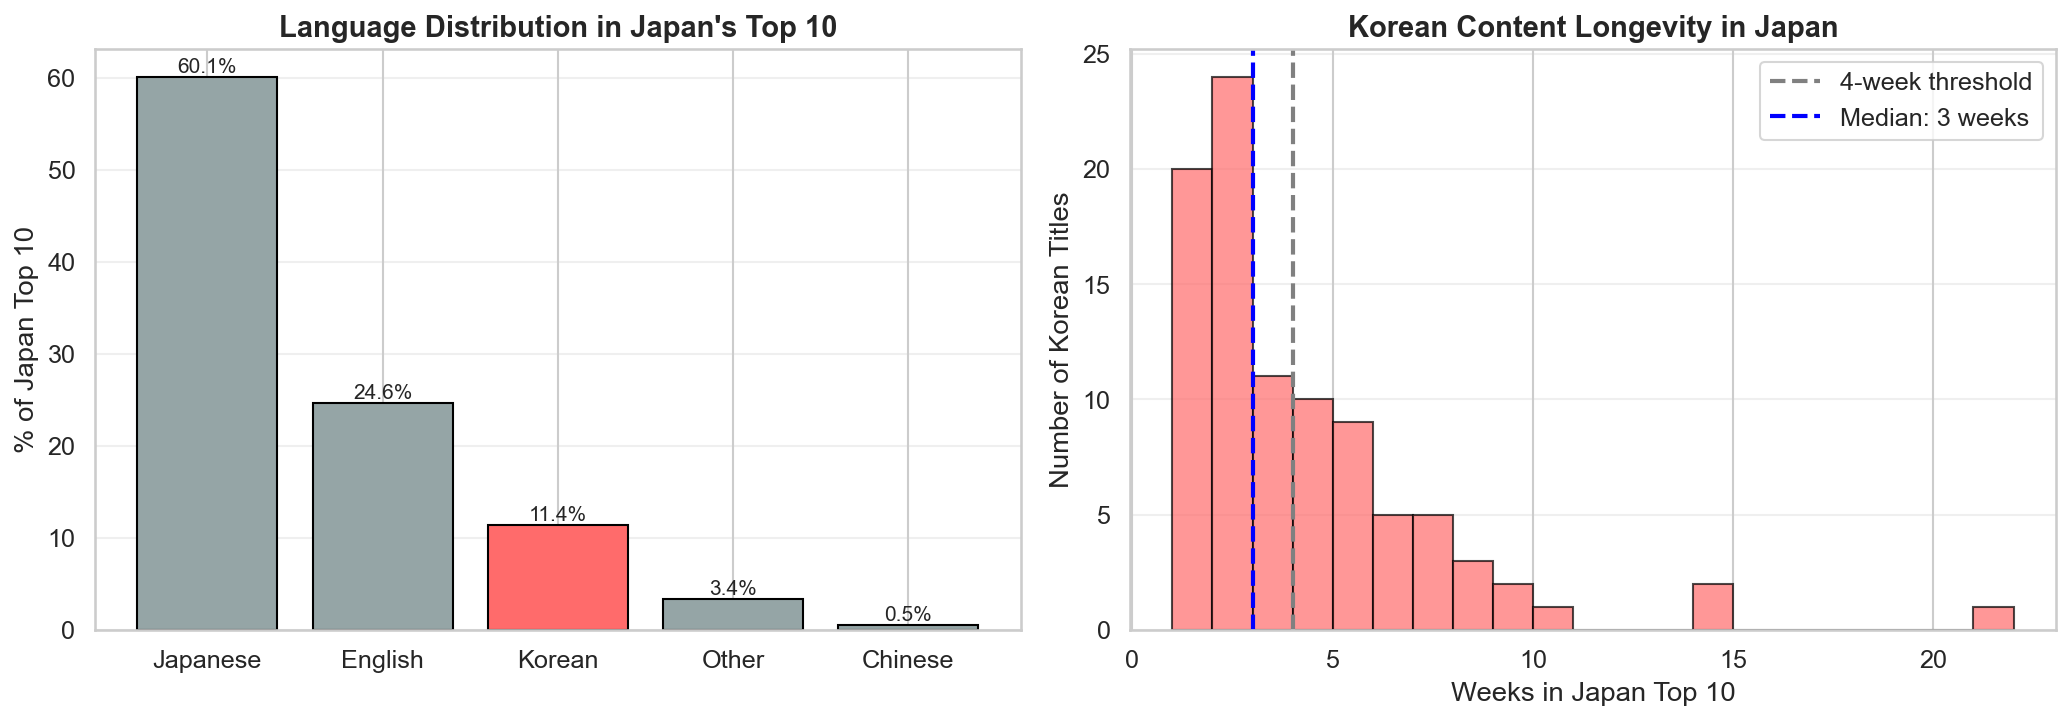

In [53]:
# Visualization: Penetration and Concentration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Language share in Japan's Top 10
jp_lang = jp_gw["original_language"].map(
    {"ko": "Korean", "en": "English", "ja": "Japanese", "zh": "Chinese"}
).fillna("Other").value_counts(normalize=True) * 100

colors = ["#FF6B6B" if lang == "Korean" else "#95A5A6" for lang in jp_lang.index]
bars = axes[0].bar(jp_lang.index, jp_lang.values, color=colors, edgecolor="black")
axes[0].set_ylabel("% of Japan Top 10")
axes[0].set_title("Language Distribution in Japan's Top 10", fontsize=14, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Add percentage labels
for bar, pct in zip(bars, jp_lang.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", fontsize=10)

# 2. Korean content longevity distribution
axes[1].hist(kr_jp_weeks, bins=range(1, int(kr_jp_weeks.max())+2), 
             color="#FF6B6B", alpha=0.7, edgecolor="black")
axes[1].axvline(4, color="gray", linestyle="--", linewidth=2, label="4-week threshold")
axes[1].axvline(kr_jp_weeks.median(), color="blue", linestyle="--", linewidth=2,
               label=f"Median: {kr_jp_weeks.median():.0f} weeks")
axes[1].set_xlabel("Weeks in Japan Top 10")
axes[1].set_ylabel("Number of Korean Titles")
axes[1].set_title("Korean Content Longevity in Japan", fontsize=14, fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

---

# Finding 2: What Travels

**Drama-Comedy with high quality ratings and standard episode lengths succeed in Japan.**

**Crime, Mystery, and Action genres do NOT travel as well.**

In [6]:
# Compare Korean content that reaches Japan vs stays in Korea only
korean_kr = kr_gw[kr_gw["original_language"] == "ko"]
korean_jp = jp_gw[jp_gw["original_language"] == "ko"]

kr_korean_titles = set(korean_kr["show_title"].unique())
jp_korean_titles = set(korean_jp["show_title"].unique())

# Titles that traveled vs stayed
traveled_to_japan = kr_korean_titles & jp_korean_titles
korea_only = kr_korean_titles - jp_korean_titles

print("="*60)
print("KOREAN CONTENT: WHAT TRAVELS TO JAPAN")
print("="*60)
print(f"\n📊 Title Distribution:")
print(f"   • Traveled to Japan: {len(traveled_to_japan)} titles")
print(f"   • Korea-only: {len(korea_only)} titles")
print(f"   • Travel rate: {len(traveled_to_japan)/(len(traveled_to_japan)+len(korea_only))*100:.1f}%")

KOREAN CONTENT: WHAT TRAVELS TO JAPAN

📊 Title Distribution:
   • Traveled to Japan: 82 titles
   • Korea-only: 255 titles
   • Travel rate: 24.3%


In [54]:
# Genre analysis: What travels vs what doesn't
def get_genre_distribution(df):
    genre_df = df.dropna(subset=["genres"]).copy()
    genre_df = genre_df.assign(genre=genre_df["genres"].str.split("|")).explode("genre")
    genre_df["genre"] = genre_df["genre"].str.strip()
    return genre_df["genre"].value_counts(normalize=True) * 100

# Get unique title-level data
traveled_data = korean_kr[korean_kr["show_title"].isin(traveled_to_japan)].drop_duplicates("show_title")
korea_only_data = korean_kr[korean_kr["show_title"].isin(korea_only)].drop_duplicates("show_title")

traveled_genres = get_genre_distribution(traveled_data)
korea_only_genres = get_genre_distribution(korea_only_data)

genre_comparison = pd.DataFrame({
    "Traveled to Japan": traveled_genres,
    "Korea Only": korea_only_genres
}).fillna(0)
genre_comparison["Difference"] = genre_comparison["Traveled to Japan"] - genre_comparison["Korea Only"]
genre_comparison = genre_comparison.sort_values("Difference", ascending=False)

print("\n📊 GENRES THAT TRAVEL WELL (+3pp or more in Japan):")
for genre in genre_comparison[genre_comparison["Difference"] > 3].index:
    jp_pct = genre_comparison.loc[genre, "Traveled to Japan"]
    kr_pct = genre_comparison.loc[genre, "Korea Only"]
    diff = genre_comparison.loc[genre, "Difference"]
    print(f"   ✅ {genre:15s}: {jp_pct:5.1f}% vs {kr_pct:5.1f}% (+{diff:.1f}pp)")

print("\n📊 GENRES THAT DON'T TRAVEL (-3pp or more in Japan):")
for genre in genre_comparison[genre_comparison["Difference"] < -3].index:
    jp_pct = genre_comparison.loc[genre, "Traveled to Japan"]
    kr_pct = genre_comparison.loc[genre, "Korea Only"]
    diff = abs(genre_comparison.loc[genre, "Difference"])
    print(f"   ❌ {genre:15s}: {jp_pct:5.1f}% vs {kr_pct:5.1f}% (-{diff:.1f}pp)")


📊 GENRES THAT TRAVEL WELL (+3pp or more in Japan):
   ✅ Drama          :  39.6% vs  23.8% (+15.7pp)
   ✅ Sci-Fi & Fantasy:   8.8% vs   2.3% (+6.4pp)
   ✅ Action & Adventure:   6.0% vs   1.1% (+5.0pp)
   ✅ Comedy         :  17.0% vs  13.0% (+4.0pp)

📊 GENRES THAT DON'T TRAVEL (-3pp or more in Japan):
   ❌ Action         :   3.3% vs   6.7% (-3.4pp)
   ❌ Thriller       :   2.7% vs   6.9% (-4.1pp)
   ❌ Reality        :   1.6% vs   9.0% (-7.4pp)


In [55]:
# Quality comparison
traveled_rated = traveled_data[(traveled_data["tmdb_rating"].notna()) & (traveled_data["tmdb_rating"] > 0)]
korea_only_rated = korea_only_data[(korea_only_data["tmdb_rating"].notna()) & (korea_only_data["tmdb_rating"] > 0)]

avg_traveled = traveled_rated["tmdb_rating"].mean()
avg_korea_only = korea_only_rated["tmdb_rating"].mean()

print("\n📊 QUALITY METRICS (TMDB Rating):")
print(f"   • Traveled to Japan: {avg_traveled:.2f} (n={len(traveled_rated)})")
print(f"   • Korea-only:        {avg_korea_only:.2f} (n={len(korea_only_rated)})")
print(f"   • Difference:        {avg_traveled - avg_korea_only:+.2f}")
print(f"\n💡 Content that travels has HIGHER quality ratings.")


📊 QUALITY METRICS (TMDB Rating):
   • Traveled to Japan: 7.80 (n=82)
   • Korea-only:        7.15 (n=232)
   • Difference:        +0.65

💡 Content that travels has HIGHER quality ratings.


In [9]:
# Episode count analysis (TV only)
traveled_tv = traveled_data[traveled_data["category"] == "TV"]
korea_only_tv = korea_only_data[korea_only_data["category"] == "TV"]

if "num_episodes" in traveled_tv.columns:
    traveled_eps = traveled_tv["num_episodes"].dropna()
    korea_only_eps = korea_only_tv["num_episodes"].dropna()
    
    def episode_bucket(ep):
        if ep <= 8: return "Short (≤8)"
        elif ep <= 16: return "Standard (9-16)"
        elif ep <= 24: return "Long (17-24)"
        else: return "Very Long (25+)"
    
    traveled_buckets = traveled_eps.apply(episode_bucket).value_counts(normalize=True) * 100
    korea_only_buckets = korea_only_eps.apply(episode_bucket).value_counts(normalize=True) * 100
    
    print("\n📊 EPISODE LENGTH DISTRIBUTION:")
    print(f"{'Episode Count':<20} {'Traveled':<15} {'Korea Only':<15}")
    print("-"*50)
    for bucket in ["Short (≤8)", "Standard (9-16)", "Long (17-24)", "Very Long (25+)"]:
        t_pct = traveled_buckets.get(bucket, 0)
        k_pct = korea_only_buckets.get(bucket, 0)
        print(f"{bucket:<20} {t_pct:>10.1f}%     {k_pct:>10.1f}%")
    
    print(f"\n💡 Standard-length shows (9-16 episodes) travel better.")


📊 EPISODE LENGTH DISTRIBUTION:
Episode Count        Traveled        Korea Only     
--------------------------------------------------
Short (≤8)                 20.0%           19.3%
Standard (9-16)            71.4%           57.0%
Long (17-24)                5.7%            5.2%
Very Long (25+)             2.9%           18.5%

💡 Standard-length shows (9-16 episodes) travel better.


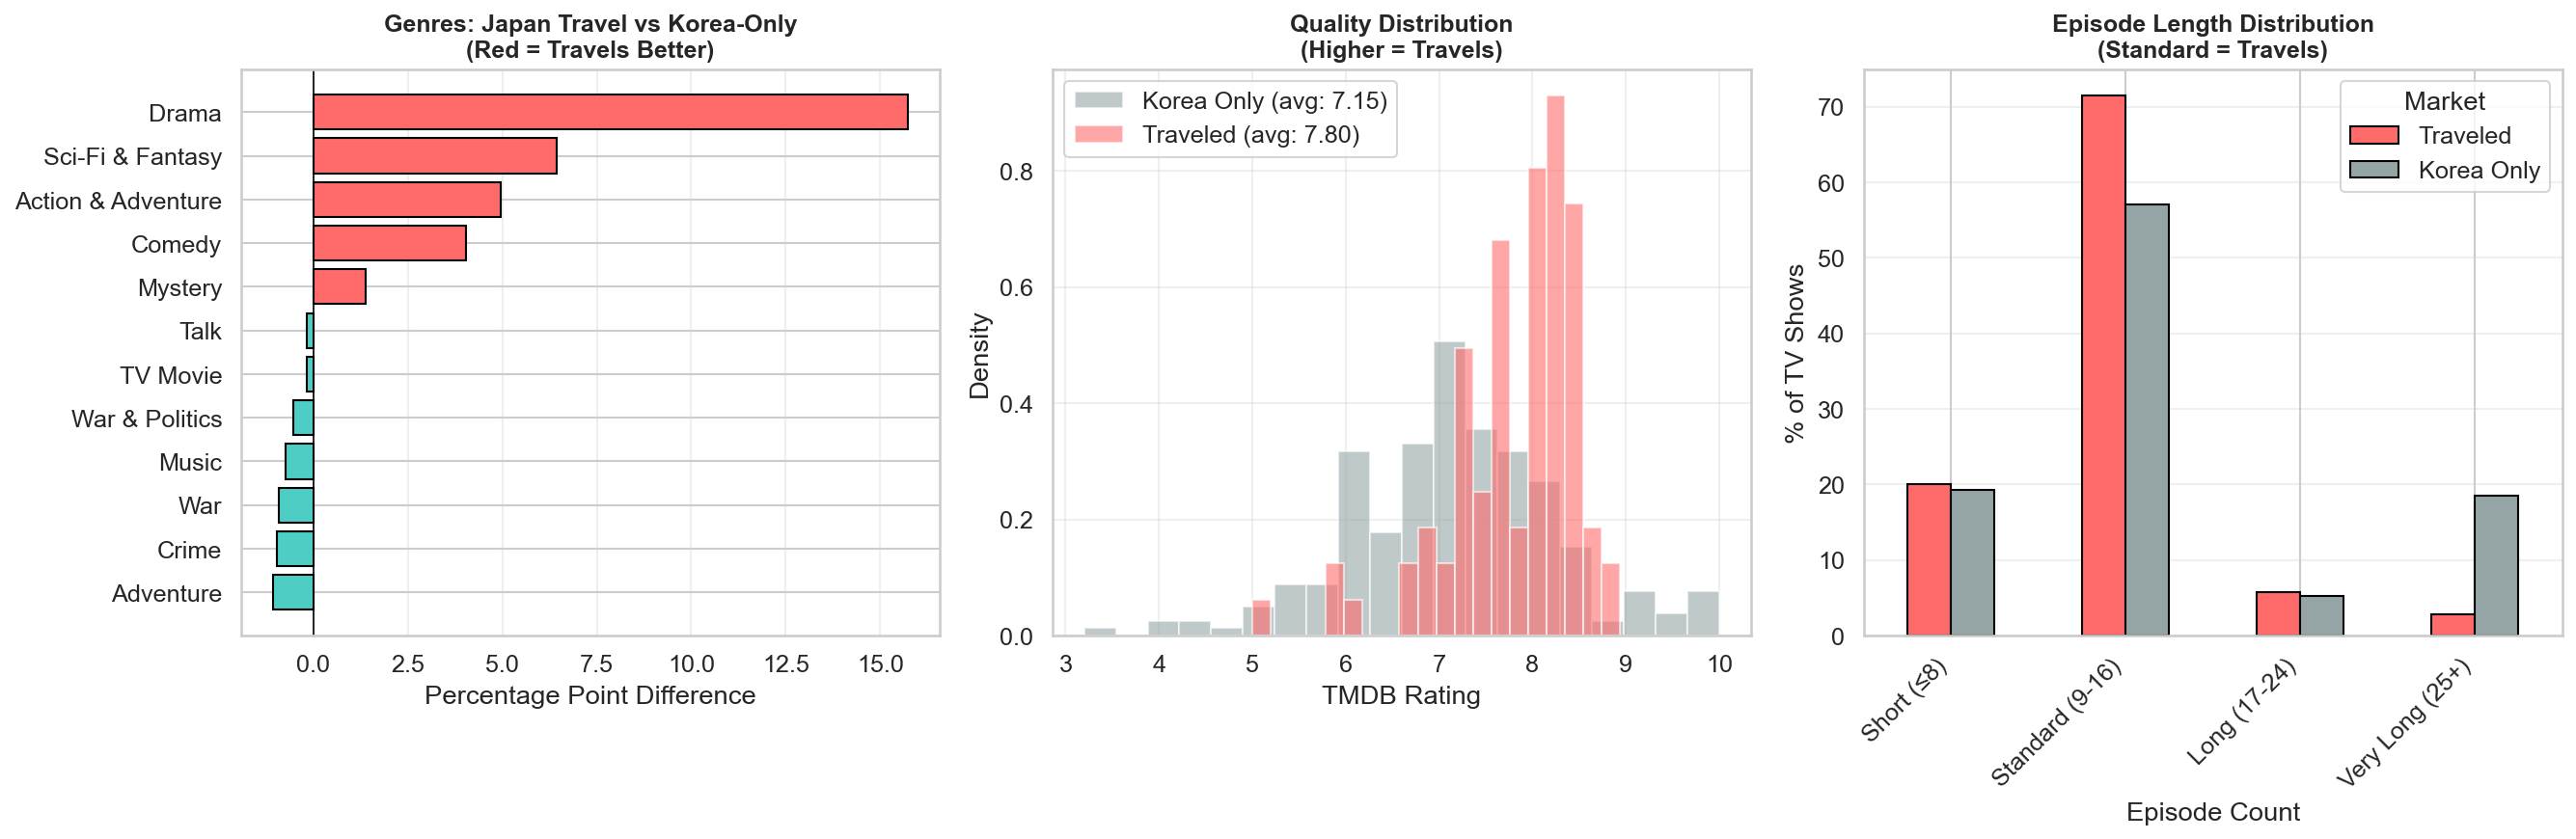

In [10]:
# Visualization: What travels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Genre difference chart
top_genres = genre_comparison.head(12)
colors = ["#FF6B6B" if x > 0 else "#4ECDC4" for x in top_genres["Difference"]]
axes[0].barh(range(len(top_genres)), top_genres["Difference"], color=colors, edgecolor="black")
axes[0].set_yticks(range(len(top_genres)))
axes[0].set_yticklabels(top_genres.index)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Percentage Point Difference")
axes[0].set_title("Genres: Japan Travel vs Korea-Only\n(Red = Travels Better)", fontsize=12, fontweight="bold")
axes[0].grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()

# 2. Quality distribution
axes[1].hist(korea_only_rated["tmdb_rating"], bins=20, alpha=0.6, 
            label=f"Korea Only (avg: {avg_korea_only:.2f})", color="#95A5A6", density=True)
axes[1].hist(traveled_rated["tmdb_rating"], bins=20, alpha=0.6,
            label=f"Traveled (avg: {avg_traveled:.2f})", color="#FF6B6B", density=True)
axes[1].set_xlabel("TMDB Rating")
axes[1].set_ylabel("Density")
axes[1].set_title("Quality Distribution\n(Higher = Travels)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Episode count comparison
if "num_episodes" in traveled_tv.columns:
    ep_comp = pd.DataFrame({
        "Traveled": traveled_buckets,
        "Korea Only": korea_only_buckets
    }).fillna(0)
    ep_comp = ep_comp.reindex(["Short (≤8)", "Standard (9-16)", "Long (17-24)", "Very Long (25+)"])
    ep_comp.plot.bar(ax=axes[2], color=["#FF6B6B", "#95A5A6"], edgecolor="black")
    axes[2].set_xlabel("Episode Count")
    axes[2].set_ylabel("% of TV Shows")
    axes[2].set_title("Episode Length Distribution\n(Standard = Travels)", fontsize=12, fontweight="bold")
    axes[2].legend(title="Market")
    axes[2].grid(axis="y", alpha=0.3)
    plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

fig.tight_layout()
plt.show()

---

# Finding 3: What Doesn't Travel (and Why)

**The majority of Korean titles that reach Japan have SHORT RUNS (≤4 weeks).**

**The bar for sustained engagement in Japan is HIGH.**

In [57]:
# Detailed breakdown of Korean content performance in Japan
print("="*60)
print("KOREAN CONTENT LONGEVITY IN JAPAN")
print("="*60)

# Statistics
print(f"\n📊 Summary Statistics:")
print(f"   • Total Korean titles in Japan: {len(kr_jp_weeks)}")
print(f"   • Average weeks: {kr_jp_weeks.mean():.1f}")
print(f"   • Median weeks: {kr_jp_weeks.median():.0f}")
print(f"   • Max weeks: {kr_jp_weeks.max():.0f}")

# Short run rate
short_run_rate = short_run / len(kr_jp_weeks) * 100
print(f"\n⚠️  SHORT RUN RATE: {short_run_rate:.1f}% of Korean titles")
print(f"   stay in Japan's Top 10 for 4 weeks or LESS.")

print(f"\n💡 The bar for sustained engagement in Japan is HIGH.")

KOREAN CONTENT LONGEVITY IN JAPAN

📊 Summary Statistics:
   • Total Korean titles in Japan: 93
   • Average weeks: 3.8
   • Median weeks: 3
   • Max weeks: 21

⚠️  SHORT RUN RATE: 69.9% of Korean titles
   stay in Japan's Top 10 for 4 weeks or LESS.

💡 The bar for sustained engagement in Japan is HIGH.


In [58]:
# Compare characteristics: 5+ weeks success vs ≤4 weeks
korean_jp_data = korean_jp.drop_duplicates("show_title").copy()
korean_jp_data["weeks"] = korean_jp_data["show_title"].map(kr_jp_weeks)

success_5plus = korean_jp_data[korean_jp_data["weeks"] >= 5]
short_run_data = korean_jp_data[korean_jp_data["weeks"] <= 4]

print("\n📊 COMPARING SUCCESS (5+ weeks) vs SHORT RUN (≤4 weeks):")
print(f"\n   Sample sizes: Success={len(success_5plus)}, Short Run={len(short_run_data)}")

# Quality comparison
success_rated = success_5plus[(success_5plus["tmdb_rating"].notna()) & (success_5plus["tmdb_rating"] > 0)]
short_rated = short_run_data[(short_run_data["tmdb_rating"].notna()) & (short_run_data["tmdb_rating"] > 0)]

print(f"\n   TMDB Rating:")
print(f"   • Success (5+ weeks): {success_rated['tmdb_rating'].mean():.2f}")
print(f"   • Short run (≤4 weeks): {short_rated['tmdb_rating'].mean():.2f}")
print(f"   • Gap: {success_rated['tmdb_rating'].mean() - short_rated['tmdb_rating'].mean():+.2f}")


📊 COMPARING SUCCESS (5+ weeks) vs SHORT RUN (≤4 weeks):

   Sample sizes: Success=28, Short Run=65

   TMDB Rating:
   • Success (5+ weeks): 7.83
   • Short run (≤4 weeks): 7.69
   • Gap: +0.15


In [59]:
# Genre comparison: Success vs Short Run
success_genres = get_genre_distribution(success_5plus)
short_genres = get_genre_distribution(short_run_data)

success_genre_comp = pd.DataFrame({
    "5+ Weeks": success_genres,
    "≤4 Weeks": short_genres
}).fillna(0)
success_genre_comp["Difference"] = success_genre_comp["5+ Weeks"] - success_genre_comp["≤4 Weeks"]
success_genre_comp = success_genre_comp.sort_values("Difference", ascending=False)

print("\n📊 GENRES IN SUCCESSFUL (5+w) vs SHORT RUN (≤4w):")
print("\n   Genres that SUCCEED:")
for genre in success_genre_comp[success_genre_comp["Difference"] >= 5].index[:5]:
    s_pct = success_genre_comp.loc[genre, "5+ Weeks"]
    f_pct = success_genre_comp.loc[genre, "≤4 Weeks"]
    print(f"   ✅ {genre}: {s_pct:.1f}% vs {f_pct:.1f}%")

print("\n   Genres that FAIL:")
# Lowered the threshold to -3 since the sample shift reduced the margin
for genre in success_genre_comp[success_genre_comp["Difference"] <= -3].index[:5]:
    s_pct = success_genre_comp.loc[genre, "5+ Weeks"]
    f_pct = success_genre_comp.loc[genre, "≤4 Weeks"]
    print(f"   ❌ {genre}: {s_pct:.1f}% vs {f_pct:.1f}%")


📊 GENRES IN SUCCESSFUL (5+w) vs SHORT RUN (≤4w):

   Genres that SUCCEED:
   ✅ Comedy: 25.9% vs 12.2%
   ✅ Drama: 44.8% vs 38.5%

   Genres that FAIL:
   ❌ Thriller: 1.7% vs 4.7%
   ❌ Mystery: 6.9% vs 10.1%
   ❌ Crime: 5.2% vs 9.5%
   ❌ Action & Adventure: 1.7% vs 6.1%


---

# Finding 4: Key Differentiators for 5+ Weeks Success (TV Dramas)

**What separates the breakout hits from the short-run shows?**
We analyze specific features of Korean TV Dramas that achieved 5+ weeks in Japan's Top 10 vs those that fell out quickly.

In [60]:
# Filter Korean TV content in Japan with 5+ weeks
kr_tv_in_japan = jp_gw[(jp_gw["original_language"] == "ko") & (jp_gw["category"] == "TV")].copy()
kr_tv_longevity = kr_tv_in_japan.groupby("show_title")["cumulative_weeks_in_top_10"].max()

# Split into success tiers
successful_titles = kr_tv_longevity[kr_tv_longevity >= 5].index
less_successful_titles = kr_tv_longevity[kr_tv_longevity < 5].index

kr_tv_successful = kr_tv_in_japan[kr_tv_in_japan["show_title"].isin(successful_titles)].drop_duplicates("show_title")
kr_tv_less_successful = kr_tv_in_japan[kr_tv_in_japan["show_title"].isin(less_successful_titles)].drop_duplicates("show_title")

# Add weeks column for analysis
kr_tv_successful["weeks_in_top10"] = kr_tv_successful["show_title"].map(kr_tv_longevity)
kr_tv_less_successful["weeks_in_top10"] = kr_tv_less_successful["show_title"].map(kr_tv_longevity)

print("="*80)
print("FEATURE ANALYSIS: KR DRAMAS WITH 5+ WEEKS TOP 10 SUCCESS IN JAPAN")
print("="*80)

print(f"\nKorean TV dramas in Japan Top 10:")
print(f"  • 5+ weeks success: {len(kr_tv_successful)} titles")
print(f"  • ≤4 weeks: {len(kr_tv_less_successful)} titles")

FEATURE ANALYSIS: KR DRAMAS WITH 5+ WEEKS TOP 10 SUCCESS IN JAPAN

Korean TV dramas in Japan Top 10:
  • 5+ weeks success: 27 titles
  • ≤4 weeks: 50 titles


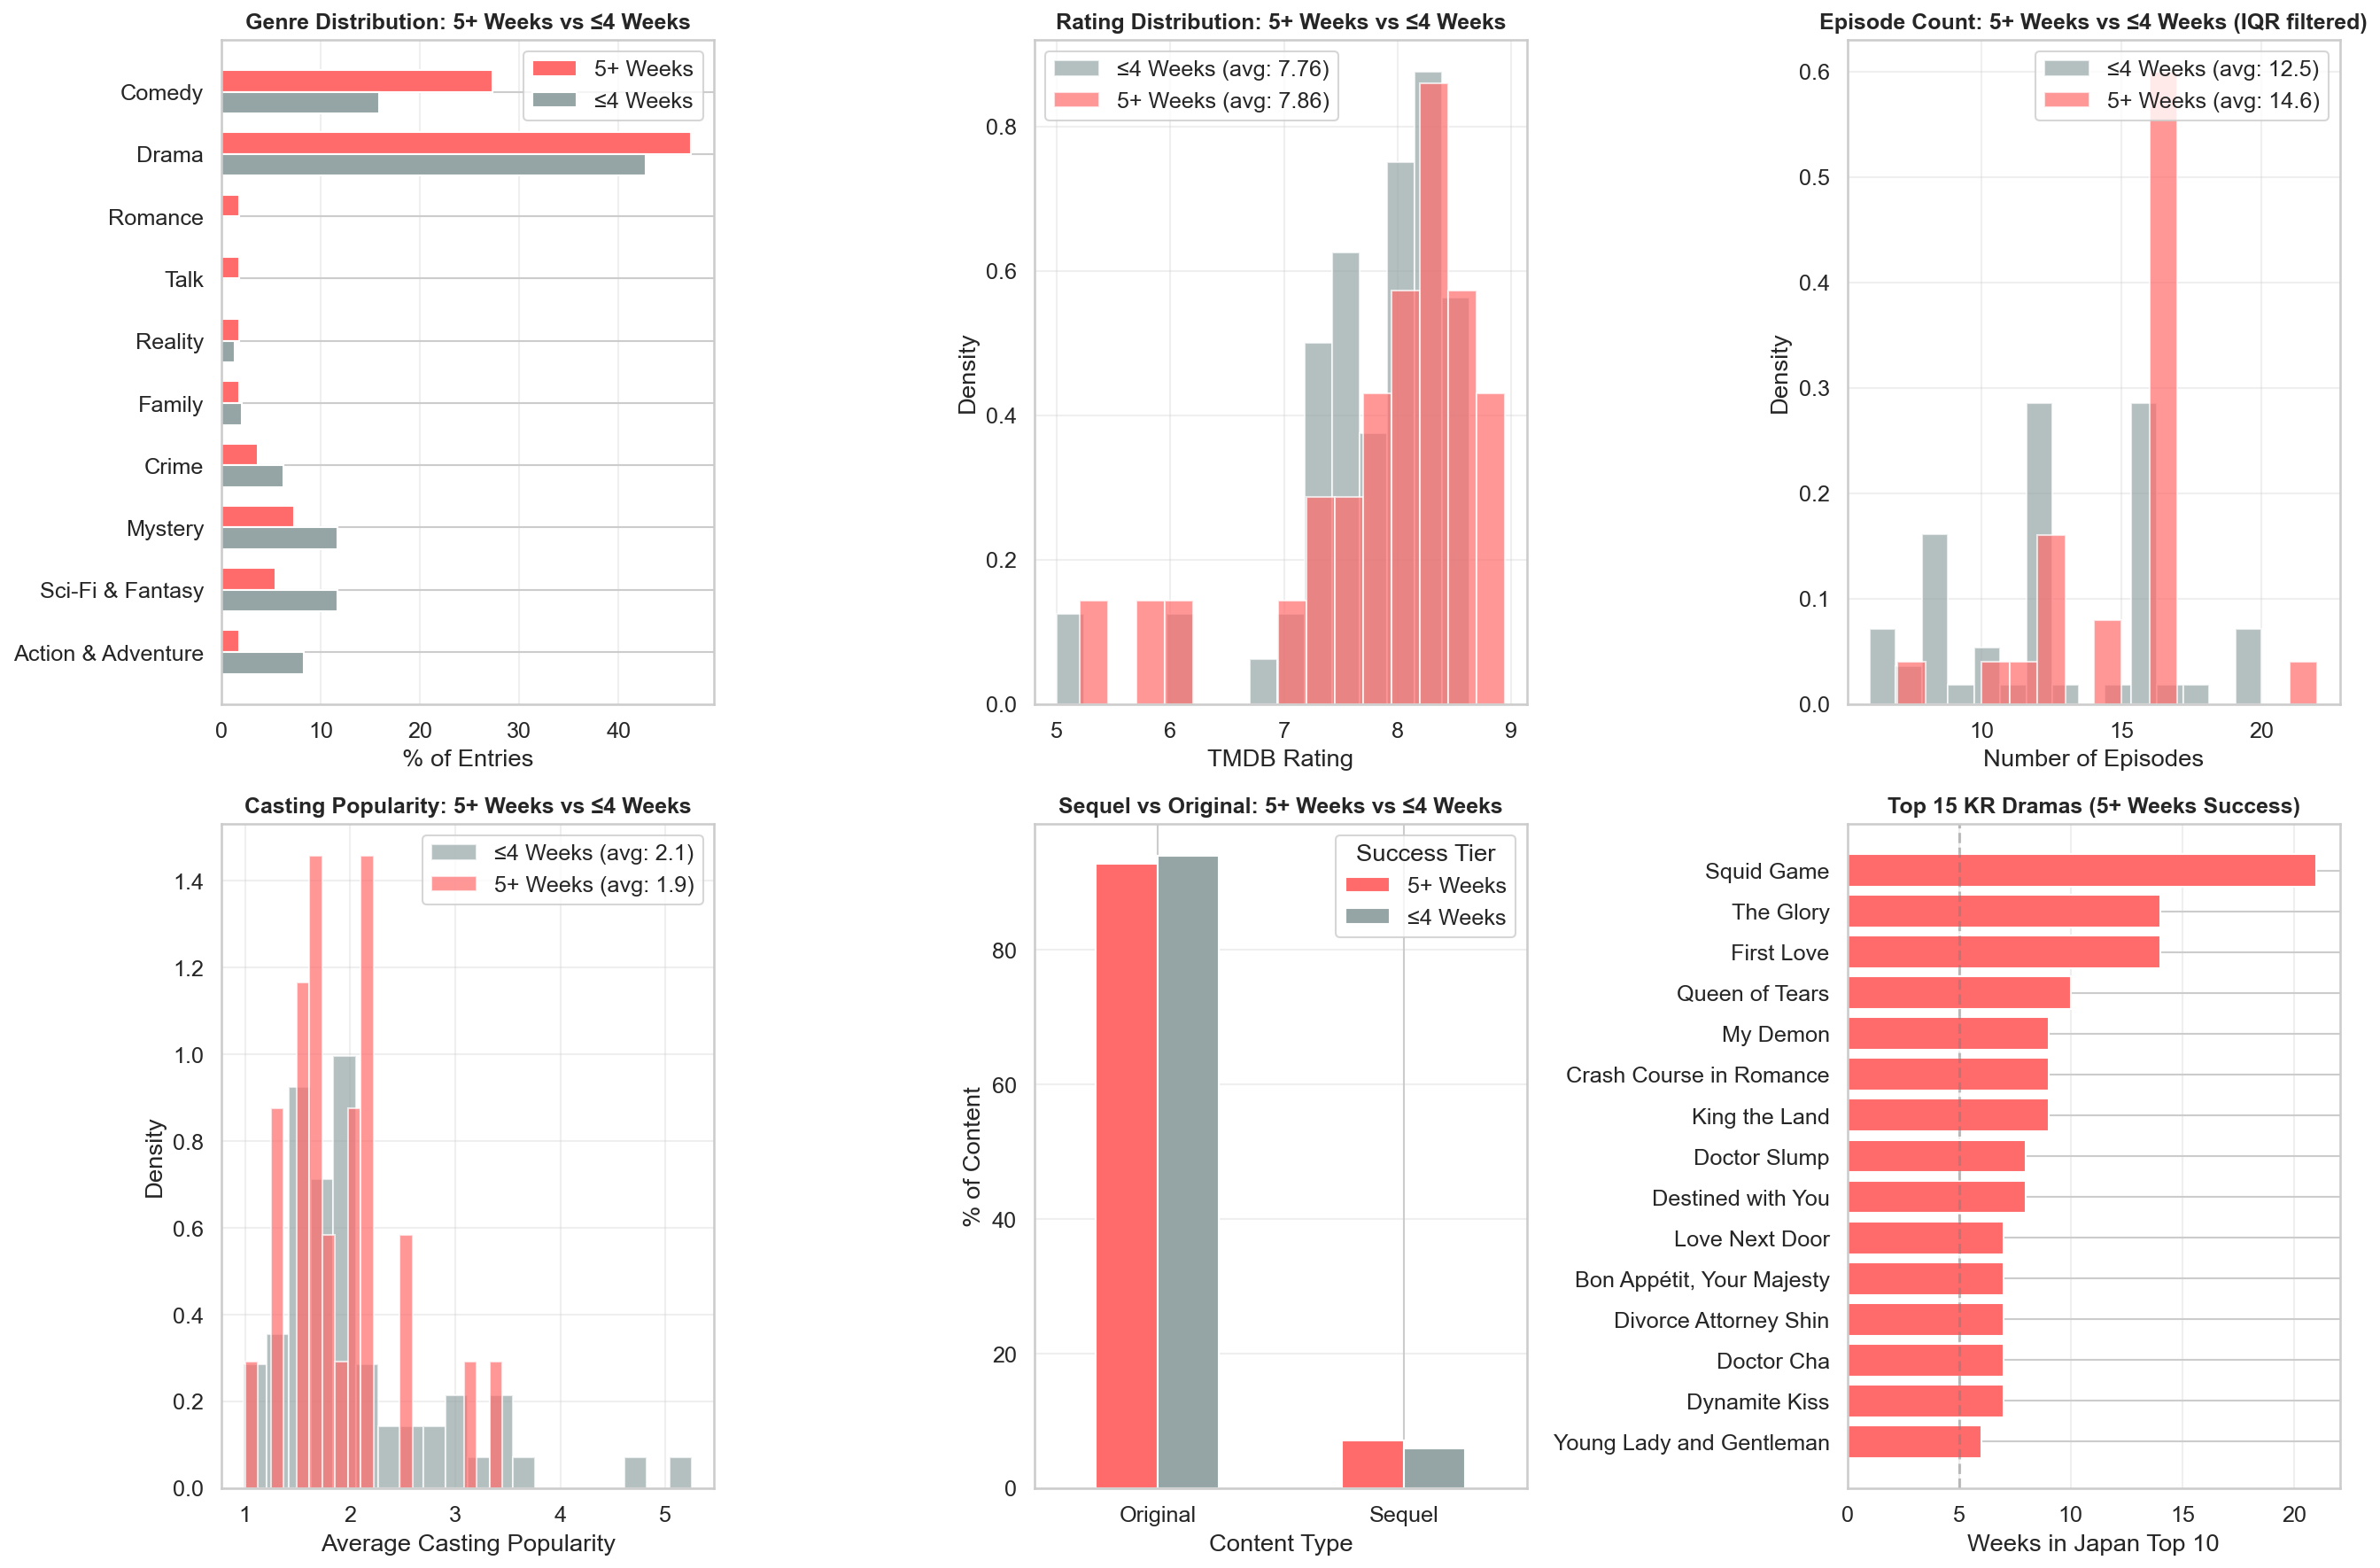

In [42]:
# VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Calculate required variables for visualization

# 1. Genre comparison
success_genre_dist = get_genre_distribution(kr_tv_successful)
less_success_genre_dist = get_genre_distribution(kr_tv_less_successful)

genre_success_comp = pd.DataFrame({
    "5+ Weeks": success_genre_dist,
    "≤4 Weeks": less_success_genre_dist
}).fillna(0)
genre_success_comp["Difference"] = genre_success_comp["5+ Weeks"] - genre_success_comp["≤4 Weeks"]
genre_success_comp = genre_success_comp.sort_values("Difference", ascending=False)
top_genres_success = genre_success_comp.head(10)

# 2. Rating distribution
success_rated = kr_tv_successful[(kr_tv_successful["tmdb_rating"].notna()) & (kr_tv_successful["tmdb_rating"] > 0)]
less_success_rated = kr_tv_less_successful[(kr_tv_less_successful["tmdb_rating"].notna()) & (kr_tv_less_successful["tmdb_rating"] > 0)]

# 3. Episode count
if "num_episodes" in kr_tv_successful.columns:
    success_episodes = kr_tv_successful["num_episodes"].dropna()
    less_success_episodes = kr_tv_less_successful["num_episodes"].dropna()
else:
    success_episodes = pd.Series(dtype=float)
    less_success_episodes = pd.Series(dtype=float)

# 4. Casting popularity
if "avg_cast_popularity" in kr_tv_successful.columns:
    success_cast = kr_tv_successful["avg_cast_popularity"]
    success_cast = success_cast[(success_cast.notna()) & (success_cast > 0)]
    less_success_cast = kr_tv_less_successful["avg_cast_popularity"]
    less_success_cast = less_success_cast[(less_success_cast.notna()) & (less_success_cast > 0)]
else:
    success_cast = pd.Series(dtype=float)
    less_success_cast = pd.Series(dtype=float)

# 5. Sequel status
if "is_sequel" in kr_tv_successful.columns:
    success_sequel_rate = kr_tv_successful["is_sequel"].mean() * 100
    less_success_sequel_rate = kr_tv_less_successful["is_sequel"].mean() * 100
else:
    success_sequel_rate = 0
    less_success_sequel_rate = 0


# Plots

# 1. Genre comparison (top 10 genres)
x = np.arange(len(top_genres_success))
width = 0.35

axes[0, 0].barh(x - width/2, top_genres_success["5+ Weeks"], width, label="5+ Weeks", color="#FF6B6B")
axes[0, 0].barh(x + width/2, top_genres_success["≤4 Weeks"], width, label="≤4 Weeks", color="#95A5A6")
axes[0, 0].set_yticks(x)
axes[0, 0].set_yticklabels(top_genres_success.index)
axes[0, 0].set_xlabel("% of Entries")
axes[0, 0].set_title("Genre Distribution: 5+ Weeks vs ≤4 Weeks", fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# 2. Rating distribution
if len(success_rated) > 0 and len(less_success_rated) > 0:
    axes[0, 1].hist(less_success_rated["tmdb_rating"], bins=15, alpha=0.7,
                    label=f"≤4 Weeks (avg: {less_success_rated['tmdb_rating'].mean():.2f})",
                    color="#95A5A6", density=True)
    axes[0, 1].hist(success_rated["tmdb_rating"], bins=15, alpha=0.7,
                    label=f"5+ Weeks (avg: {success_rated['tmdb_rating'].mean():.2f})",
                    color="#FF6B6B", density=True)
    axes[0, 1].set_xlabel("TMDB Rating")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].set_title("Rating Distribution: 5+ Weeks vs ≤4 Weeks", fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

# 3. Episode count distribution
if len(success_episodes) > 0:
    all_eps = pd.concat([success_episodes, less_success_episodes])
    ep_Q1, ep_Q3 = all_eps.quantile(0.25), all_eps.quantile(0.75)
    ep_IQR = ep_Q3 - ep_Q1
    ep_lower, ep_upper = ep_Q1 - 1.5 * ep_IQR, ep_Q3 + 1.5 * ep_IQR
    
    success_eps_filtered = success_episodes[(success_episodes >= ep_lower) & (success_episodes <= ep_upper)]
    less_eps_filtered = less_success_episodes[(less_success_episodes >= ep_lower) & (less_success_episodes <= ep_upper)]
    
    axes[0, 2].hist(less_eps_filtered, bins=15, alpha=0.7,
                    label=f"≤4 Weeks (avg: {less_eps_filtered.mean():.1f})",
                    color="#95A5A6", density=True)
    axes[0, 2].hist(success_eps_filtered, bins=15, alpha=0.7,
                    label=f"5+ Weeks (avg: {success_eps_filtered.mean():.1f})",
                    color="#FF6B6B", density=True)
    axes[0, 2].set_xlabel("Number of Episodes")
    axes[0, 2].set_ylabel("Density")
    axes[0, 2].set_title("Episode Count: 5+ Weeks vs ≤4 Weeks (IQR filtered)", fontsize=12, fontweight='bold')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)

# 4. Casting popularity
if len(success_cast) > 0:
    axes[1, 0].hist(less_success_cast, bins=20, alpha=0.7,
                    label=f"≤4 Weeks (avg: {less_success_cast.mean():.1f})",
                    color="#95A5A6", density=True)
    axes[1, 0].hist(success_cast, bins=20, alpha=0.7,
                    label=f"5+ Weeks (avg: {success_cast.mean():.1f})",
                    color="#FF6B6B", density=True)
    axes[1, 0].set_xlabel("Average Casting Popularity")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].set_title("Casting Popularity: 5+ Weeks vs ≤4 Weeks", fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

# 5. Sequel status comparison
if "is_sequel" in kr_tv_successful.columns:
    sequel_comp = pd.DataFrame({
        "5+ Weeks": [100-success_sequel_rate, success_sequel_rate],
        "≤4 Weeks": [100-less_success_sequel_rate, less_success_sequel_rate]
    }, index=["Original", "Sequel"])
    
    sequel_comp.plot.bar(ax=axes[1, 1], color=["#FF6B6B", "#95A5A6"])
    axes[1, 1].set_xlabel("Content Type")
    axes[1, 1].set_ylabel("% of Content")
    axes[1, 1].set_title("Sequel vs Original: 5+ Weeks vs ≤4 Weeks", fontsize=12, fontweight='bold')
    axes[1, 1].legend(title="Success Tier")
    axes[1, 1].grid(axis='y', alpha=0.3)
    plt.setp(axes[1, 1].get_xticklabels(), rotation=0)

# 6. Top 15 successful titles
top_performers = kr_tv_successful.sort_values("weeks_in_top10", ascending=False)
top_15_success = top_performers.head(15)
axes[1, 2].barh(range(len(top_15_success)), top_15_success["weeks_in_top10"], color="#FF6B6B")
axes[1, 2].set_yticks(range(len(top_15_success)))
axes[1, 2].set_yticklabels([title[:30] + "..." if len(title) > 30 else title
                            for title in top_15_success["show_title"]])
axes[1, 2].set_xlabel("Weeks in Japan Top 10")
axes[1, 2].set_title("Top 15 KR Dramas (5+ Weeks Success)", fontsize=12, fontweight='bold')
axes[1, 2].axvline(x=5, color='gray', linestyle='--', alpha=0.5, label="5 week threshold")
axes[1, 2].grid(axis='x', alpha=0.3)
axes[1, 2].invert_yaxis()

fig.tight_layout()
plt.show()

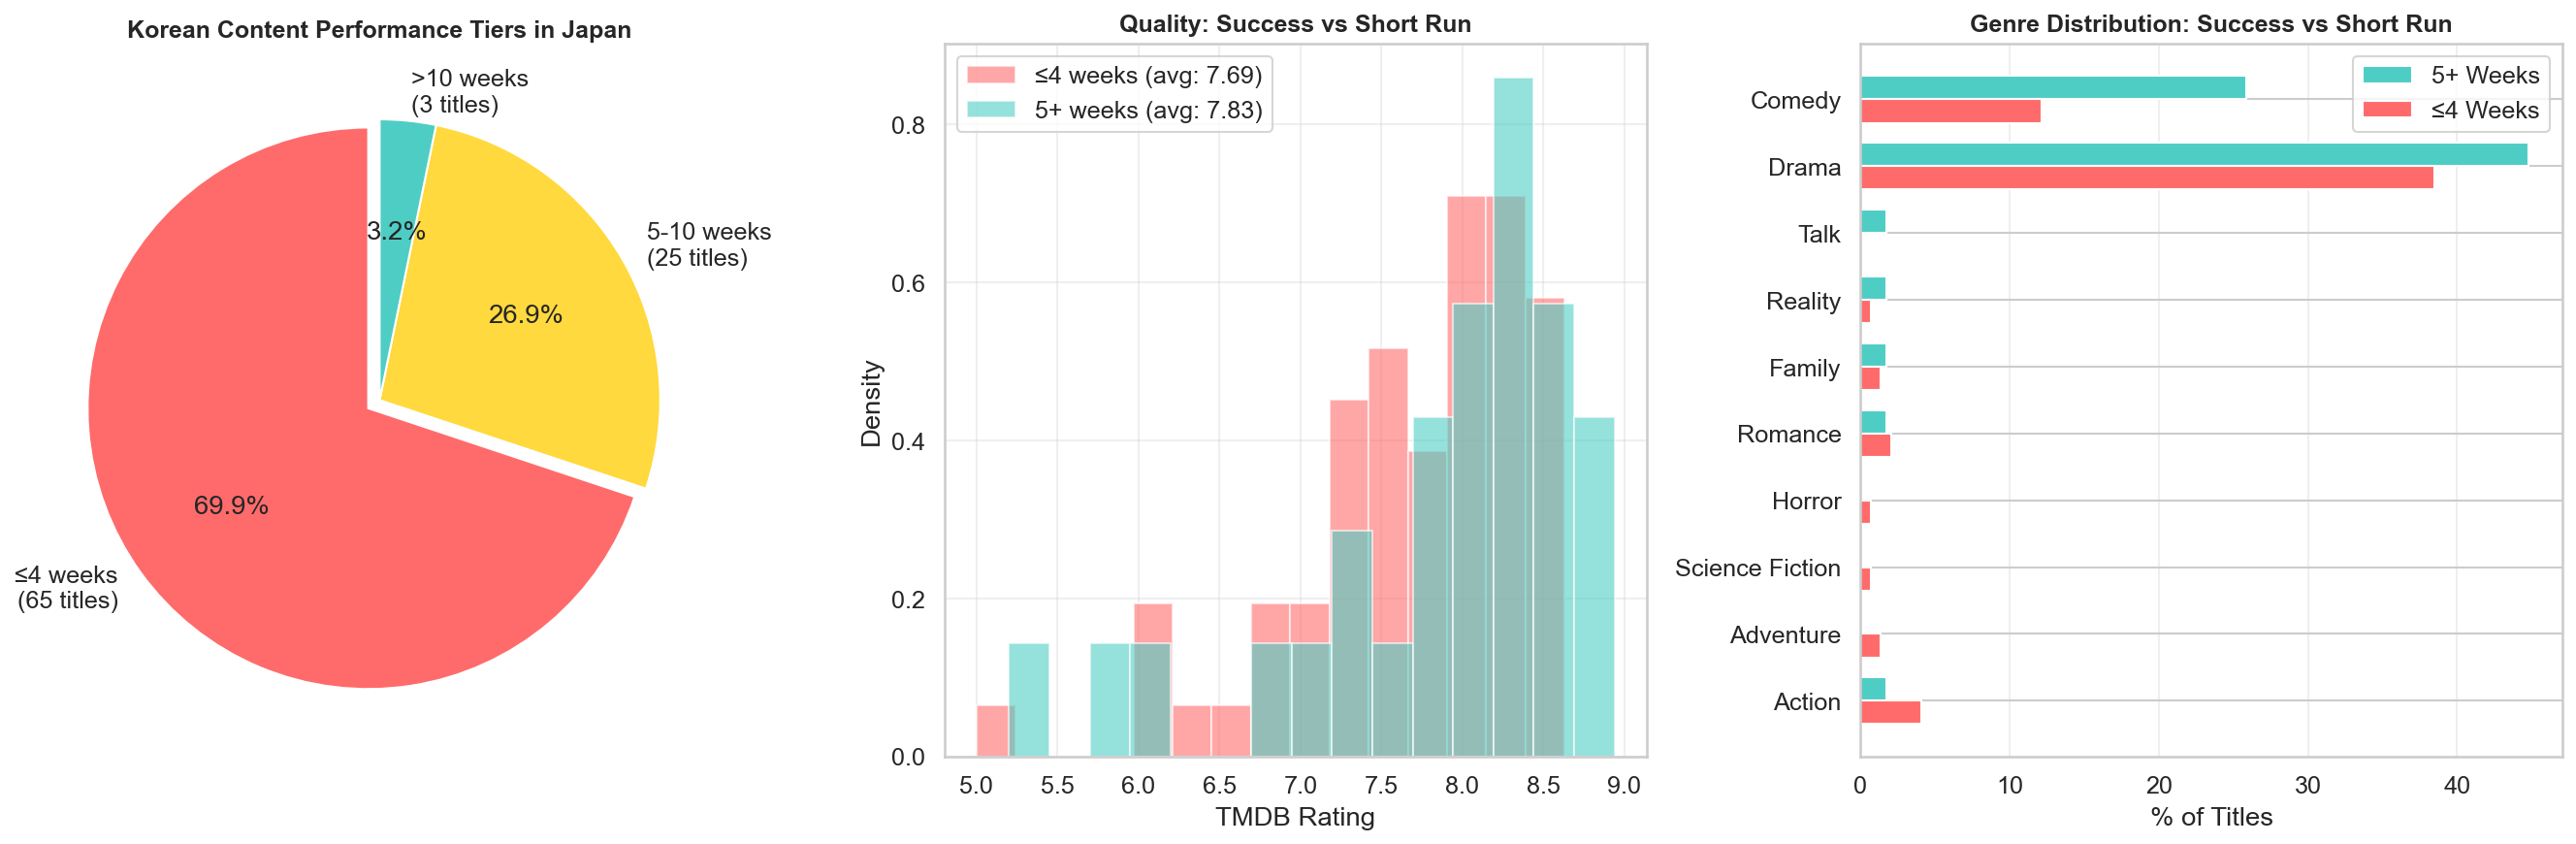

In [61]:
# Visualization: Success vs Failure patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Performance tier distribution
tier_data = [short_run, medium_run, long_run]
tier_labels = [f"≤4 weeks\n({short_run} titles)", 
               f"5-10 weeks\n({medium_run} titles)",
               f">10 weeks\n({long_run} titles)"]
tier_colors = ["#FF6B6B", "#FFD93D", "#4ECDC4"]

axes[0].pie(tier_data, labels=tier_labels, colors=tier_colors, autopct="%1.1f%%",
           startangle=90, explode=(0.05, 0, 0))
axes[0].set_title("Korean Content Performance Tiers in Japan", fontsize=12, fontweight="bold")

# 2. Quality comparison
if len(success_rated) > 0 and len(short_rated) > 0:
    axes[1].hist(short_rated["tmdb_rating"], bins=15, alpha=0.6,
                label=f"≤4 weeks (avg: {short_rated['tmdb_rating'].mean():.2f})",
                color="#FF6B6B", density=True)
    axes[1].hist(success_rated["tmdb_rating"], bins=15, alpha=0.6,
                label=f"5+ weeks (avg: {success_rated['tmdb_rating'].mean():.2f})",
                color="#4ECDC4", density=True)
    axes[1].set_xlabel("TMDB Rating")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Quality: Success vs Short Run", fontsize=12, fontweight="bold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

# 3. Genre comparison
top_genre_comp = success_genre_comp.head(10)
x = np.arange(len(top_genre_comp))
width = 0.35

axes[2].barh(x - width/2, top_genre_comp["5+ Weeks"], width, label="5+ Weeks", color="#4ECDC4")
axes[2].barh(x + width/2, top_genre_comp["≤4 Weeks"], width, label="≤4 Weeks", color="#FF6B6B")
axes[2].set_yticks(x)
axes[2].set_yticklabels(top_genre_comp.index)
axes[2].set_xlabel("% of Titles")
axes[2].set_title("Genre Distribution: Success vs Short Run", fontsize=12, fontweight="bold")
axes[2].legend()
axes[2].grid(axis="x", alpha=0.3)
axes[2].invert_yaxis()

fig.tight_layout()
plt.show()

---

# Recommendation: Commissioning Criteria for Japan Market

Based on the analysis, here are concrete commissioning criteria for Korean content targeting Japan:

In [62]:
# Calculate specific thresholds for recommendations
print("="*70)
print("COMMISSIONING CRITERIA FOR KOREAN CONTENT → JAPAN")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  RECOMMENDED CRITERIA                                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. GENRE SELECTION                                                 │
│     ✅ PRIORITIZE: Drama, Comedy, Romance                          │
│     ⚠️  CAUTION: Crime, Mystery, Action (lower travel rates)       │
│                                                                     │
│  2. QUALITY THRESHOLD                                               │""")
print(f"│     ✅ Target TMDB rating: ≥{avg_traveled:.1f} (successful content average)    │")
print("""│     ✅ High production value is essential                        │
│                                                                     │
│  3. FORMAT SPECIFICATIONS                                           │
│     ✅ Standard episode length: 9-16 episodes                       │
│     ✅ TV dramas perform better than films                          │
│                                                                     │
│  4. CASTING                                                         │
│     ✅ Higher star power correlates with Japan success              │
│     ✅ Consider actors with existing Japan recognition              │
│                                                                     │
│  5. LONGEVITY EXPECTATION                                           │""")
print(f"│     ⚠️  ~{short_run_rate:.0f}% of Korean content has short runs (≤4 weeks)    │")
print("""│     ✅ Plan marketing for sustained engagement                    │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
""")

COMMISSIONING CRITERIA FOR KOREAN CONTENT → JAPAN

┌─────────────────────────────────────────────────────────────────────┐
│  RECOMMENDED CRITERIA                                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. GENRE SELECTION                                                 │
│     ✅ PRIORITIZE: Drama, Comedy, Romance                          │
│     ⚠️  CAUTION: Crime, Mystery, Action (lower travel rates)       │
│                                                                     │
│  2. QUALITY THRESHOLD                                               │
│     ✅ Target TMDB rating: ≥7.8 (successful content average)    │
│     ✅ High production value is essential                        │
│                                                                     │
│  3. FORMAT SPECIFICATIONS                                           │
│     ✅ Standard episode 

In [63]:
# Top performing examples
top_kr_japan = korean_jp.groupby("show_title").agg({
    "cumulative_weeks_in_top_10": "max",
    "genres": "first",
    "tmdb_rating": "first",
    "category": "first"
}).sort_values("cumulative_weeks_in_top_10", ascending=False)

print("\n📊 TOP 15 KOREAN TITLES IN JAPAN (Reference Examples):")
print("="*80)
print(f"{'Rank':<5} {'Title':<40} {'Weeks':<8} {'Rating':<8} {'Genre'}")
print("-"*80)

for i, (title, row) in enumerate(top_kr_japan.head(15).iterrows(), 1):
    genres_short = str(row['genres'])[:25] + "..." if pd.notna(row['genres']) and len(str(row['genres'])) > 25 else str(row.get('genres', 'N/A'))
    rating = f"{row['tmdb_rating']:.1f}" if pd.notna(row['tmdb_rating']) else "N/A"
    print(f"{i:<5} {title[:38]:<40} {row['cumulative_weeks_in_top_10']:<8.0f} {rating:<8} {genres_short}")


📊 TOP 15 KOREAN TITLES IN JAPAN (Reference Examples):
Rank  Title                                    Weeks    Rating   Genre
--------------------------------------------------------------------------------
1     Squid Game                               21       7.9      Action & Adventure|Myster...
2     The Glory                                14       8.5      Drama
3     First Love                               14       5.2      Romance|Drama
4     Queen of Tears                           10       8.4      Drama|Comedy
5     My Demon                                 9        8.5      Drama|Comedy
6     Crash Course in Romance                  9        8.2      Drama|Comedy
7     King the Land                            9        8.2      Drama|Comedy
8     Destined with You                        8        8.1      Drama|Sci-Fi & Fantasy|Co...
9     Doctor Slump                             8        8.2      Drama|Comedy
10    Doctor Cha                               7        8.0      

---

# Summary

| Finding | Key Insight |
|---------|-------------|
| **Scale** | Korean content = ~11% of Japan's Top 10, but heavily concentrated |
| **What Travels** | Drama-Comedy, high quality (TMDB ≥7.5), standard length (9-16 eps) |
| **What Doesn't** | Thriller/Crime/Mystery/Action; ~70% of Korean titles are short runs (≤4 weeks) |
| **Recommendation** | Focus on quality Drama-Comedy with star power; expect high failure rate |

---

*Analysis based on Netflix Top 10 data enriched with TMDB metadata.*